In [1]:
import joblib
from pathlib import Path
import numpy as npa
import matplotlib.pyplot as plt
import qutip
from tqdm import tqdm

In [2]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [3]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar

In [4]:
import joblib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import qutip
from tqdm import tqdm

In [5]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [6]:
import seaborn as sns

# sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.2)
sns.set(
    context="paper",
    style="white",
    palette="colorblind",
    font_scale=1.2,
    rc={
        "font.family": "DejaVu Sans",  # или "Liberation Sans", "Arial"
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    },
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 301/301 [00:40<00:00,  7.40it/s, n27m7k27,27,27p27t0;0.7853981633974483;301;fids]


Text(0, 0.5, 'Fidelity, F')

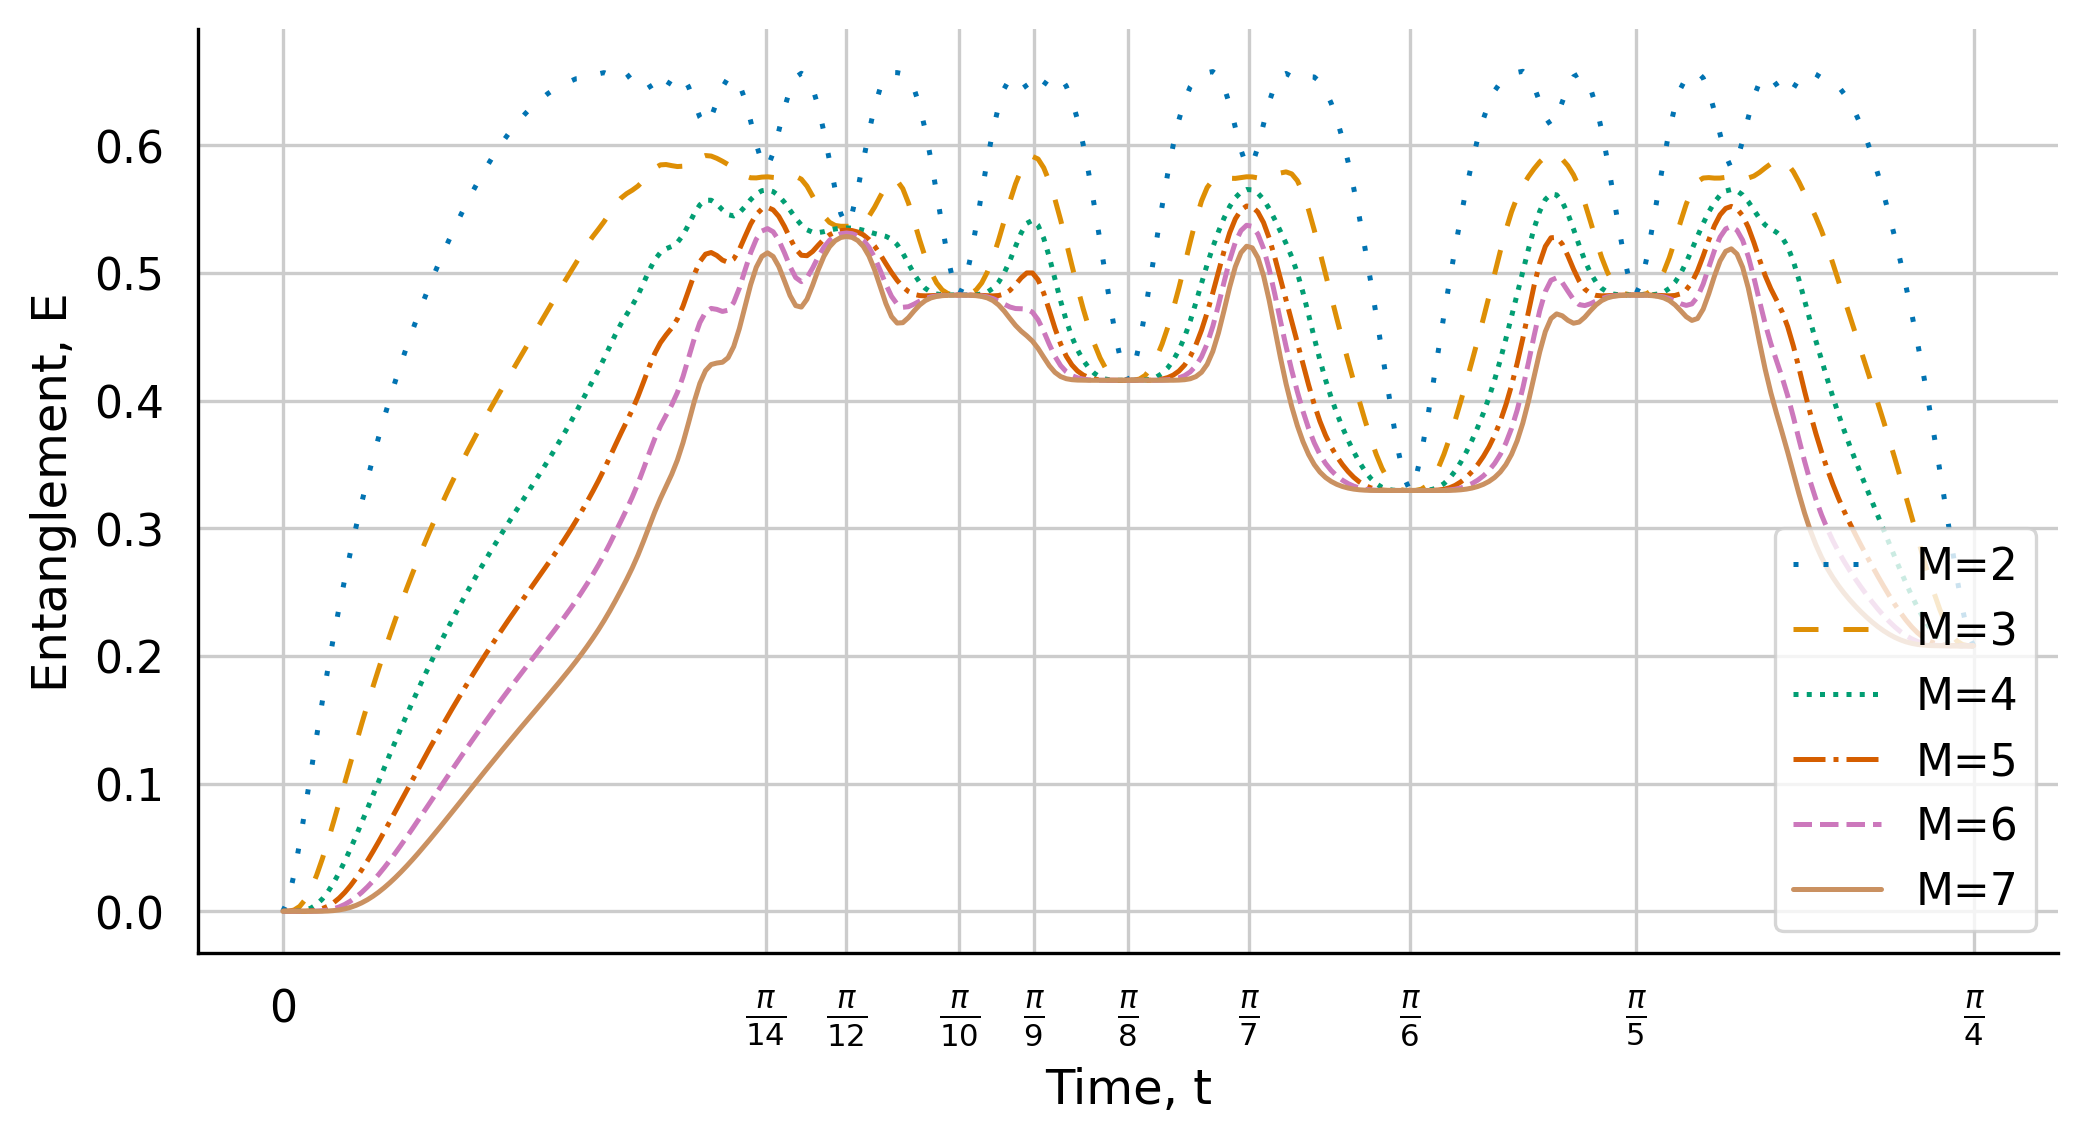

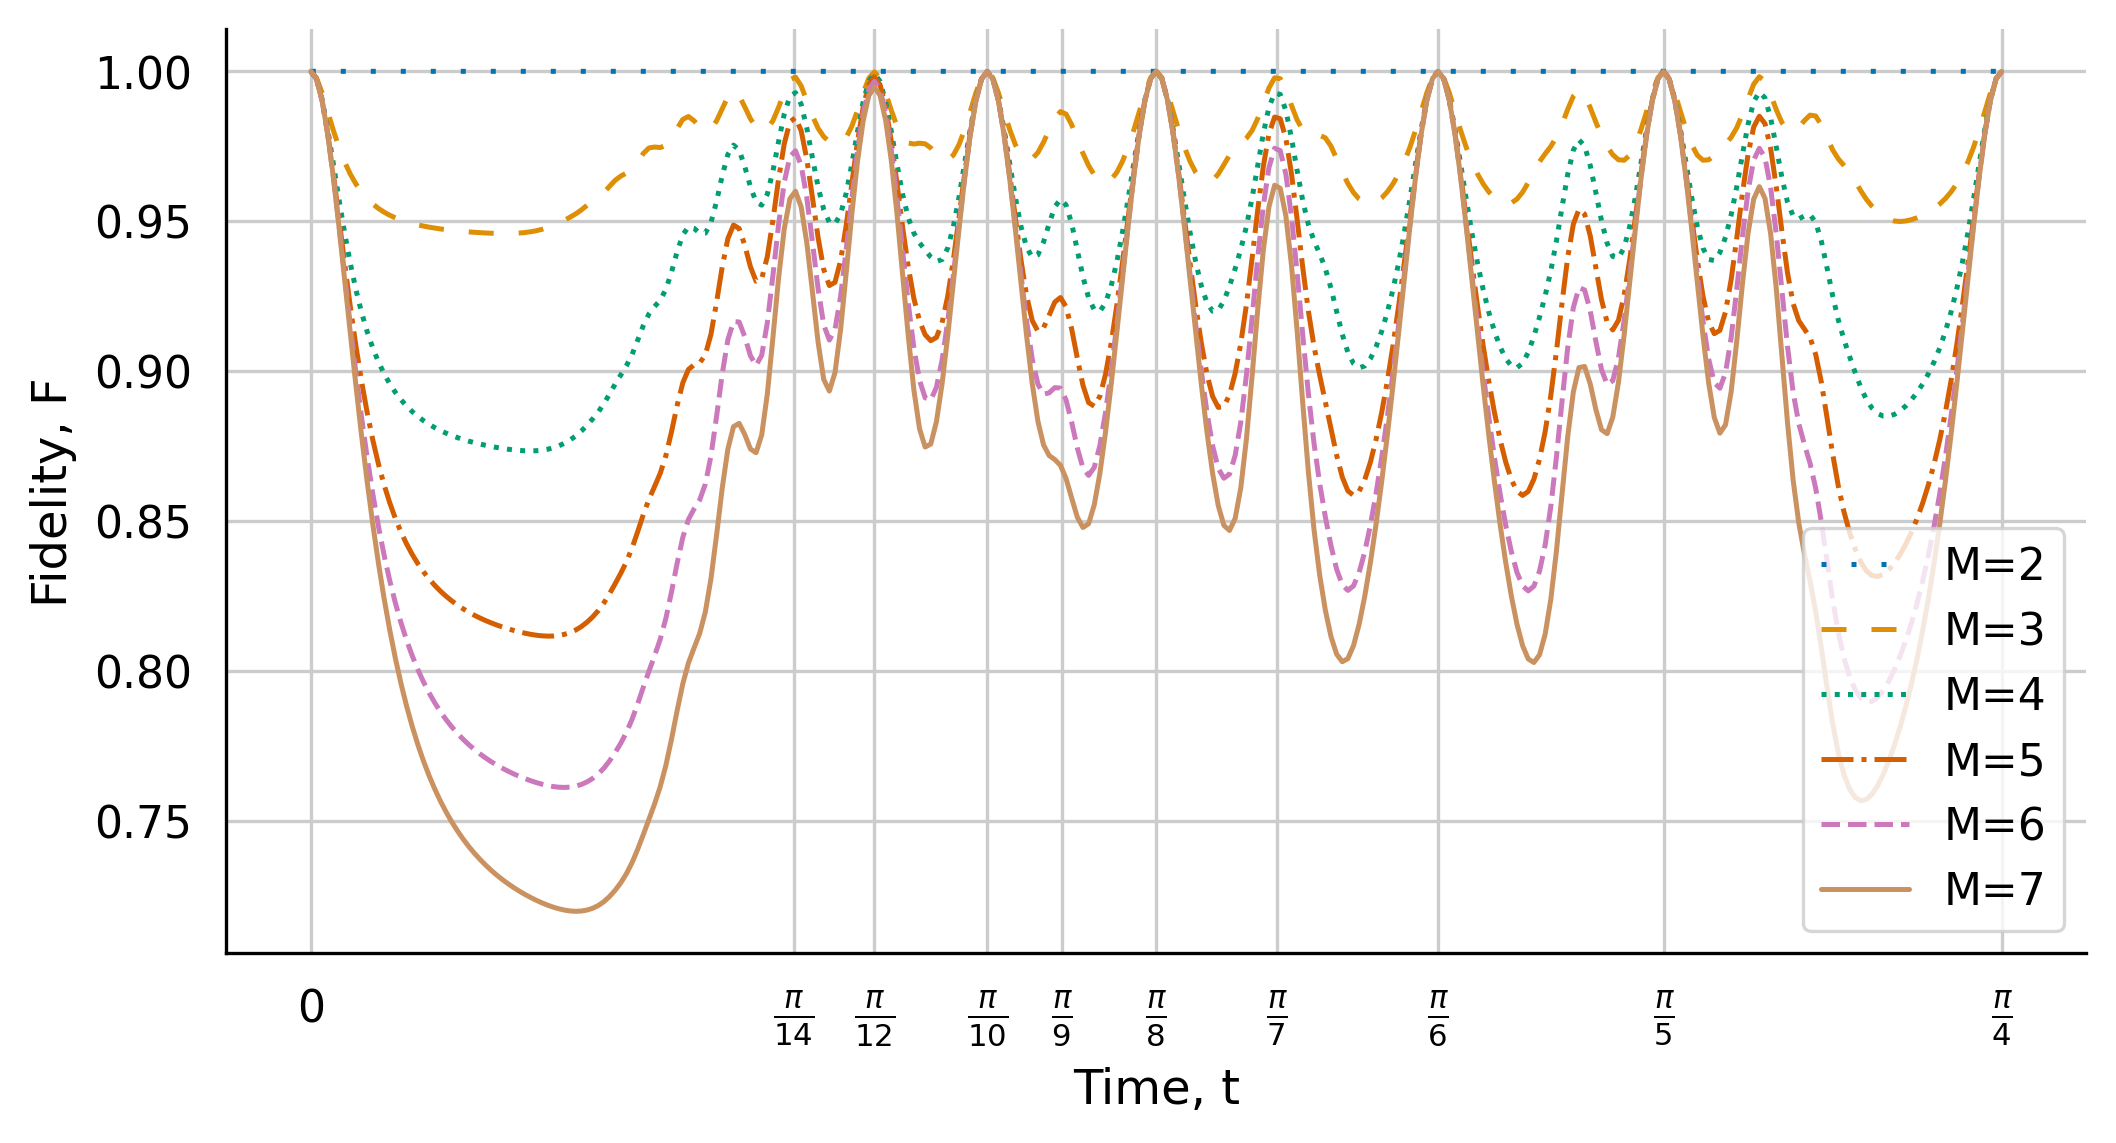

In [7]:
plot_exact = False

n_bosons = 27
t_span = (0, np.pi / 4, 301)

n_jobs = -2

t_list = np.linspace(*t_span)
model_ = bec.BEC_Qubits.init_default(n_bosons, 0)
states_true = joblib.Parallel(n_jobs=n_jobs)(
    joblib.delayed(
        lambda t, m: bec.state_under_h_zz_reduced_teor_focked(m, t / m.Omega)
    )(t, model_)
    for t in tqdm(t_list, postfix=f"n{model_.n_bosons}m2;teor", ncols=80)
)

linestyles = reversed(["-", "--", "-.", ":", (0, (5, 5)), (0, (1, 5))])
numbers_sites = [2, 3, 4, 5, 6, 7]
# numbers_sites = [2, 3, 4, 5]
# numbers_sites = []

# fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 4))
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 4))
axes = [ax1, ax2]

for m, ls in zip(numbers_sites, linestyles):
    pe_task = entanglement_propagation.PropagateEntanglementTask(
        n_bosons=n_bosons,
        n_sites=m,
        t_span=t_span,
    )
    pe_result = pe_task.run(n_jobs=n_jobs, ncols=t_span[-1])
    fids = joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(
            lambda s, s_e: qutip.metrics.fidelity(
                (sq := pe_result.to_Qobj(s)) / sq.tr(), s_e
            )
        )(s, s_e)
        for s, s_e in tqdm(
            zip(pe_result.states, states_true),
            postfix=f"{pe_task.label};fids",
            ncols=t_span[-1],
            total=len(pe_result.states),
        )
    )

    label = pe_task.label
    label = f"M={pe_task.n_sites}"
    axes[0].plot(
        pe_result.t_list,
        pe_result.entropies() / np.log2(pe_task.n_bosons + 1),
        linestyle=ls,
        label=label,
    )
    axes[1].plot(pe_result.t_list, fids, linestyle=ls, label=label)


if plot_exact:
    axes[0].plot(
        t_list,
        [
            qutip.entropy.entropy_vn(s, base=2) / np.log2(pe_task.n_bosons + 1)
            for s in states_true
        ],
        "-k",
        label=f"m2;exact",
        linewidth=1,
    )

for ax in axes:
    ax.grid()
    ax.legend(loc="lower right")
    ax.set_xlabel("Time, t")
    ax.set_xticks(
        *zip(
            *(
                ((np.pi / i, rf"$\frac{{\pi}}{{{i}}}$") if i != 0 else (0, "0"))
                if isinstance(i, int)
                else (i[0] * np.pi / i[1], rf"$\frac{{{i[0]}\pi}}{{{i[1]}}}$")
                for i in (0, 14, 12, 10, 9, 8, 7, 6, 5, 4)
            )
        )
    )

axes[0].set_ylabel("Entanglement, E")
axes[1].set_ylabel("Fidelity, F")

In [8]:
figure_path = Path("figures/")
fig1.savefig(figure_path / f"entanglement_n{n_bosons}_m{max(numbers_sites)}.pdf")
fig1.savefig(figure_path / f"entanglement_n{n_bosons}_m{max(numbers_sites)}.png")

fig2.savefig(figure_path / f"fidelity_n{n_bosons}_m{max(numbers_sites)}.pdf")
fig2.savefig(figure_path / f"fidelity_n{n_bosons}_m{max(numbers_sites)}.png")